# 22 · HID dictionary relations v1: do paid periods and word relations pay?

**Question.** Notebook 21 found that multilevel word dictionaries never paid for
themselves against the accepted k = 1 archive (A0). Many dictionary words, however, are
internally periodic or are near-copies (complement, reversal, a few flipped bits) of an
earlier word. If those words are *described through* a period or an earlier word, and
the description is paid inside the same complete archive, does any proposal become
shorter than A0?

**Design.** Same 96 exposed strings, same views (8 widths × 2 origins × 4 levels, now
*without* branch pruning) and the same proposals G0–G3. Four dictionary modes per view:
**O** the original words; **P** a word with an exact dividing period becomes
REPEAT(period base); **R(O)/R(P)** each word may be the first eligible relation to one of
the eight preceding words (complement/reversal, then at most 8 paid bit flips, relation
chains at most 8 deep). Arms: A0 (k = 1), D0 = O, D1 = O + P, D2 = O + P + R(O) + R(P).
Every candidate is a full-input archive decoded independently; ties keep A0.

Exploratory and descriptive, on exposed data: no interval, no test, no confirmation,
no fractal or causal claim. Run the first cell first.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
from pathlib import Path
_cands = [Path.cwd(), Path.cwd() / "index-deconvolution", Path(ROOT)]
ID_ROOT = next(p.resolve() for p in _cands
               if (p / "PROTOCOL_order_discovery.md").is_file()
               and (p / "results" / "hierarchy_dictionary_v1" / "dictionary-feasibility-v1-r1").is_dir())
ROOT = str(ID_ROOT)
for _p in (os.path.join(os.path.dirname(ROOT), "src"), ROOT):
    while _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("hierarchy", None)          # a sibling repo ships a module "hierarchy"
import json, hashlib, csv, collections, statistics
import numpy as np
import matplotlib.pyplot as plt
from hierarchy.decode import decode_archive                 # saved archives only
from hierarchy.ledger import archive_ledger                 # field ledger of saved bytes

RUN = ID_ROOT / "results" / "hierarchy_dictionary_v1" / "dictionary-feasibility-v1-r1"
def load(p):
    return json.loads(Path(p).read_text())
summary, decision = load(RUN / "summary.json"), load(RUN / "DECISION.json")
verification, audit = load(RUN / "verification.json"), load(RUN / "arithmetic_audit.json")
lock_sha = (RUN / "implementation_lock.sha256").read_text().strip()
def table(name):
    with open(RUN / "tables" / name) as fh:
        return list(csv.DictReader(fh))
views, gmap = table("views_D2.csv"), table("gap_map_D2.csv")
def num(x):
    return None if x in ("", "None", None) else float(x)
def arc(h):
    return (RUN / "archives" / h[:2] / f"{h}.isd").read_bytes()
print("lock:", lock_sha[:16], "| engineering verdict:", decision["engineering_verdict"],
      "| label:", decision["recommendation"])
print("verification pass:", verification["verification_pass"], "| audit pass:", audit["pass"],
      "| archives re-read by the audit:", audit["archives_read"], "| decodes:", audit["decodes"])

lock: 19b53d32873a37cf | engineering verdict: VALID_COMPLETE | label: NO_RETAINED_GAIN
verification pass: True | audit pass: True | archives re-read by the audit: 26364 | decodes: 12332


## 1. Completeness and the headline

Counts, the evidence state and the fixed label are read from `summary.json`. The label is
evaluated in the protocol's order: relation gain (D2 < D1 anywhere), then period gain
(D1 < D0), then control-only gain (D0 < A0), else no retained gain.

In [3]:
for k, v in summary["counts"].items():
    print(f"{k:34s} {v}")
rec = summary["recommendation"]
print()
print("label:", rec["label"])
for k in ("d2_beats_d1_cases", "d1_beats_d0_cases", "d0_beats_a0_cases", "d2_beats_a0_cases"):
    print(f"  {k:20s} {len(rec[k])} of {summary['counts']['strings']}")

augmentation_jobs_intended         288
augmentation_jobs_with_rows        288
augmentation_rows_valid            288
baseline_jobs_intended             96
baseline_jobs_with_rows            96
baseline_reproduced                96
derived_composite_records          288
derived_portfolio_references       96
evaluated_views_D2                 6096
imported_old_a3_problems           0
imported_old_a3_records            96
imported_reference_problems        0
imported_reference_records         864
new_encoder_jobs_intended          384
new_encoder_jobs_with_rows         384
search_complete                    288
strings                            96
traces                             288
view_records_D2                    6144
watchdog_fallbacks                 0

label: NO_RETAINED_GAIN
  d2_beats_d1_cases    0 of 96
  d1_beats_d0_cases    0 of 96
  d0_beats_a0_cases    0 of 96
  d2_beats_a0_cases    0 of 96


## 2. Contrasts, with their reference points in the same table

saving(X, Y) = (bits(Y) − bits(X)) / n, positive when X is shorter; averaged base/ragged,
then replicates (48 pairs), then the 24 family-length cells equally. The A0 rows are the
reference distribution against which every arm is read.

In [4]:
print(f"{'contrast':22s} {'equal-cell mean':>16s}  strings b/t/w (of)   pairs b/t/w    cells b/t/w")
for k, v in summary["contrasts"].items():
    s, p, c = v["strings"], v["pairs_sign"], v["cells_sign"]
    print(f"{k:22s} {v['aggregate']:16.6f}  {s['better']:3d}/{s['tie']:3d}/{s['worse']:3d} ({s['available']})  "
          f"{p['better']:2d}/{p['tie']:2d}/{p['worse']:2d}       {c['better']:2d}/{c['tie']:2d}/{c['worse']:2d}")

contrast                equal-cell mean  strings b/t/w (of)   pairs b/t/w    cells b/t/w
A0_vs_pair_grammar             0.351713   87/  0/  9 (96)  44/ 0/ 4       22/ 0/ 2
A0_vs_portfolio               -0.045188   21/ 12/ 63 (96)  11/ 6/31        5/ 3/16
D0_vs_A0                       0.000000    0/ 96/  0 (96)   0/48/ 0        0/24/ 0
D0_vs_oldA3                    0.000000    0/ 96/  0 (96)   0/48/ 0        0/24/ 0
D0_vs_pair_grammar             0.351713   87/  0/  9 (96)  44/ 0/ 4       22/ 0/ 2
D0_vs_portfolio               -0.045188   21/ 12/ 63 (96)  11/ 6/31        5/ 3/16
D1_vs_A0                       0.000000    0/ 96/  0 (96)   0/48/ 0        0/24/ 0
D1_vs_D0                       0.000000    0/ 96/  0 (96)   0/48/ 0        0/24/ 0
D1_vs_pair_grammar             0.351713   87/  0/  9 (96)  44/ 0/ 4       22/ 0/ 2
D1_vs_portfolio               -0.045188   21/ 12/ 63 (96)  11/ 6/31        5/ 3/16
D2_vs_A0                       0.000000    0/ 96/  0 (96)   0/48/ 0        0/24/ 

## 3. Rendering the object: the closest a relation mode came

For every string, the shortest R(O) archive over all views is compared with A0. The
closest case in which relations were actually used, and shortened the view's own O
proposal, is opened below: its words (hex), the relations chosen, the archive length
of each mode in that view, and the byte ledgers of the saved relation archive and of A0.
A relation can make a view's own proposal much shorter than its O proposal and still not
beat A0; equal length is a tie, and ties keep A0.

In [5]:
per = summary["mode_contributions"]["per_string"]
gap = sorted(((r["best_bits_by_mode"]["R(O)"] - r["a0_bits"]), c) for c, r in per.items())
print("strings:", len(gap), "| min (R(O) best − A0) bits:", gap[0][0],
      "| median:", statistics.median(g for g, _ in gap), "| max:", gap[-1][0])
for m in ("O", "P", "R(O)", "R(P)"):
    rel = sorted((r["best_bits_by_mode"][m] - r["a0_bits"]) / r["a0_bits"] for r in per.values())
    print(f"  mode {m:5s} relative excess of the best view over A0: min {rel[0]:.4f}  median "
          f"{statistics.median(rel):.4f}  max {rel[-1]:.3f}  (of {len(rel)})")
row0 = None
for g, cid in gap:
    row = load(RUN / "rows" / f"{cid}.D2.json")
    tr = load(RUN / row["trace_path"])
    cand = [(m["best_bits"], v["view_index"], v, m) for v in tr["views"] if v["status"] == "EVALUATED"
            for m in v["modes"] if m["mode"] == "R(O)" and m["best_bits"] is not None
            and m["construction"]["relations_selected"] > 0 and (m["minus_O_bits"] or 0) < 0]
    if cand:
        row0, (bb, vi, v, m) = row, min(cand, key=lambda t: (t[0], t[1]))
        break
print("\ncase:", row0["case_id"], "| view: width", v["width"], "level", v["level"], "origin", v["origin"],
      "| m =", v["m"], "k =", v["k"], "| A0 bits", row0["a0_archive_bits"])
for mm in v["modes"]:
    print(f"  mode {mm['mode']:5s} best {mm['best_bits']} bits ({mm['best_proposal']})  minus O: {mm['minus_O_bits']}")
words = v["dictionary"]
for w in words[:8]:
    print("  word", w["symbol"], hex(int(w["word"], 2)) if "word" in w else w)
for r in m["construction"]["relations"]:
    print("  relation:", r)

strings: 96 | min (R(O) best − A0) bits: 0 | median: 628.0 | max: 4384
  mode O     relative excess of the best view over A0: min 0.0000  median 0.5254  max 24.273  (of 96)
  mode P     relative excess of the best view over A0: min 0.0000  median 0.5201  max 24.682  (of 96)
  mode R(O)  relative excess of the best view over A0: min 0.0000  median 0.5675  max 24.909  (of 96)
  mode R(P)  relative excess of the best view over A0: min 0.0000  median 0.5124  max 24.909  (of 96)

case: confirmation-F05-1024-3000-base | view: width 4 level 3 origin 0 | m = 64 k = 2 | A0 bits 144
  mode O     best 304 bits (G2)  minus O: 0
  mode P     best 224 bits (G2)  minus O: -80
  mode R(O)  best 272 bits (G2)  minus O: -32
  mode R(P)  best 232 bits (G2)  minus O: -72
  word 0 {'lower_pair': [0, 0], 'symbol': 0}
  word 1 {'lower_pair': [1, 1], 'symbol': 1}
  relation: {'flags': 0, 'flip_positions': [3, 7, 11, 15], 'hops': 1, 'id': 1, 'j': 0}


In [6]:
data, a0 = arc(m["best_sha256"]), arc(row0["a0_archive_sha256"])
x_sha = row0["input_sha256"]
print("relation archive decodes to the input:", hashlib.sha256(decode_archive(data).encode()).hexdigest() == x_sha,
      "| A0 decodes to the input:", hashlib.sha256(decode_archive(a0).encode()).hexdigest() == x_sha)
for name, b in (("R(O) candidate", data), ("A0", a0)):
    led = archive_ledger(b)
    kinds = collections.Counter()
    if led["model"] is not None:
        names = {f"rule{i}": type(r).__name__.upper() for i, r in enumerate(led["model"].rules)}
        for f in led["fields"]:
            kinds[names.get(f["owner"], f["owner"])] += f["bytes"]
    print(f"{name:15s} {len(b):4d} bytes | ledger sums to {sum(f['bytes'] for f in led['fields'])} | "
          f"codec {led['codec']} | bytes by rule kind {dict(kinds)}")
print("deployed D2 composite is A0:", row0["archive_sha256"] == row0["a0_archive_sha256"])

relation archive decodes to the input: True | A0 decodes to the input: True
R(O) candidate    34 bytes | ledger sums to 34 | codec hid | bytes by rule kind {'envelope': 8, 'dag': 1, 'LITERAL': 3, 'CONCAT': 12, 'PATCH': 7, 'REPEAT': 3}
A0                18 bytes | ledger sums to 18 | codec hid | bytes by rule kind {'envelope': 8, 'dag': 1, 'LITERAL': 6, 'REPEAT': 3}
deployed D2 composite is A0: True


## 4. Same-view mode comparisons and the width-by-level map

Each comparison below pairs two modes *of the same view* (same words, same top stream,
same gaps, same factory), so the only difference is how the dictionary words are
described. The map pools 96 strings × 2 origins per cell; no view is pruned in this
phase, and the column "old mask would skip" counts views multilevel-v1 never evaluated.

In [7]:
mc = summary["mode_contributions"]
print(f"{'comparison':12s} {'shorter':>8s} {'equal':>8s} {'longer':>8s}   (denominator)")
for k, c in mc["same_view_comparisons"].items():
    print(f"{k:12s} {c.get('shorter', 0):8d} {c.get('equal', 0):8d} {c.get('longer', 0):8d}   "
          f"({mc['same_view_denominators'][k]})")
print("\nper view, the best archive of each mode against A0:", mc["view_mode_best_vs_a0"])
print("strings where a mode's best view beats the best O view:", mc["strings_where_mode_best_beats_O_best"])

comparison    shorter    equal   longer   (denominator)
P_vs_O            368     4787      941   (6096)
R(O)_vs_O        1243     2628     2225   (6096)
R(P)_vs_O        1359     2482     2255   (6096)
R(P)_vs_P        1263     2628     2205   (6096)

per view, the best archive of each mode against A0: {'O': {'equal': 2, 'longer': 6094}, 'P': {'equal': 2, 'longer': 6094}, 'R(O)': {'equal': 6, 'longer': 6090}, 'R(P)': {'equal': 6, 'longer': 6090}}
strings where a mode's best view beats the best O view: {'P': 2, 'R(O)': 12, 'R(P)': 14}


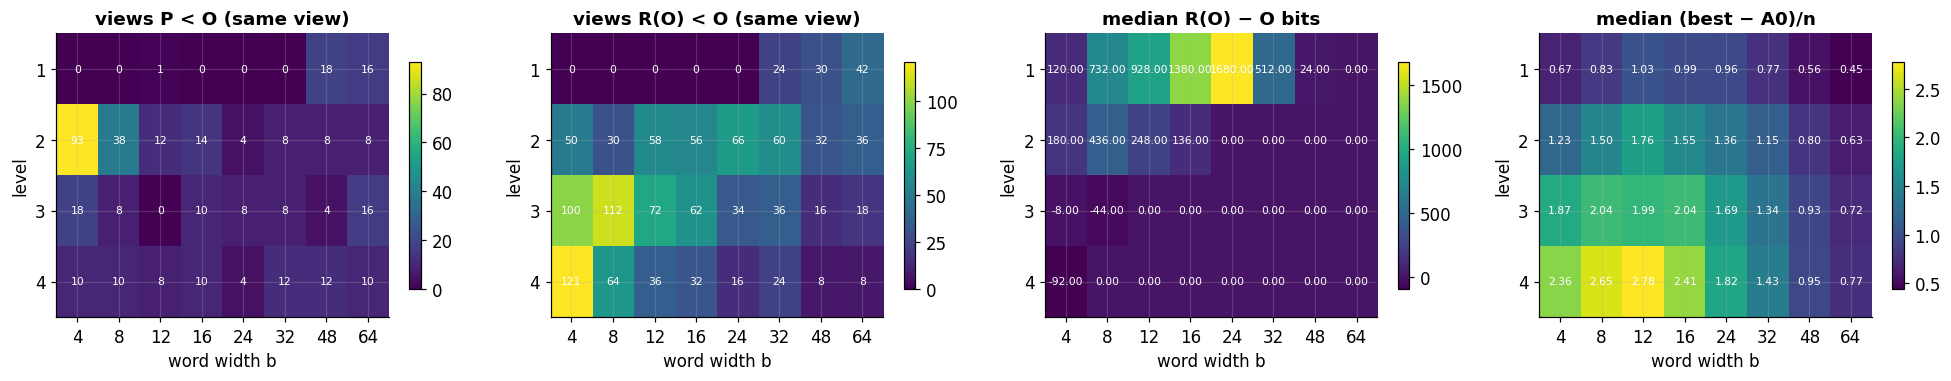

cells: 32 | evaluated view instances: 6096 | views whose best archive is shorter than A0: 0


In [8]:
W = sorted({int(g["width"]) for g in gmap}); Lv = sorted({int(g["level"]) for g in gmap})
def grid(key):
    M = np.full((len(Lv), len(W)), np.nan)
    for g in gmap:
        val = num(g[key])
        if val is not None:
            M[Lv.index(int(g["level"])), W.index(int(g["width"]))] = val
    return M
panels = [("views_P_shorter_than_O", "views P < O (same view)"),
          ("views_RO_shorter_than_O", "views R(O) < O (same view)"),
          ("median_RO_minus_O_bits", "median R(O) − O bits"),
          ("median_best_minus_a0_per_bit", "median (best − A0)/n")]
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, (key, title) in zip(axes, panels):
    M = grid(key)
    im = ax.imshow(M, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(W)), W); ax.set_yticks(range(len(Lv)), Lv)
    ax.set_xlabel("word width b"); ax.set_ylabel("level"); ax.set_title(title)
    for i in range(len(Lv)):
        for j in range(len(W)):
            if not np.isnan(M[i, j]):
                ax.text(j, i, f"{M[i, j]:.2f}" if "median" in key else f"{int(M[i, j])}",
                        ha="center", va="center", fontsize=7, color="w")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()
print("cells:", len(gmap), "| evaluated view instances:", sum(int(g["evaluated"]) for g in gmap),
      "| views whose best archive is shorter than A0:", sum(int(g["views_best_shorter_than_a0"]) for g in gmap))

## 5. What the dictionary constructions contained

Counts of periodic replacements and of selected relations (flags: 1 complement, 2
reversal, 3 both; flips are paid patch positions; hops are relation-chain depth, capped
at 8). These describe the dictionaries; they are not savings.

In [9]:
con = summary["construction"]
for k, v in con["counts"].items():
    print(f"{k:34s} {v}")
print("relation flags:", con["relation_flags"])
print("relation flip counts:", con["relation_flip_counts"])
print("relation hops:", con["relation_hops"])
for arm in ("D0", "D1", "D2"):
    c = summary["workload"][arm]["counters"]
    print(f"{arm}: requests {c['requests']}, serialized {c['serialized']}, decoded {c['decoded']}, "
          f"duplicates {c['duplicates']}, patch rejections {c['patch_rejections']}, graph rejections "
          f"{c['graph_rejections']}, relation comparisons {c['relation_comparisons']}")

dictionary_entries                 219053
evaluated_views                    6096
hop_cap_rejections_R(O)            354960
non_dividing_proper_periods        167147
period_replacements                4195
relation_comparisons_R(O)          6199208
relation_comparisons_R(P)          6199208
relations_selected_R(O)            130575
relations_selected_R(P)            130575
views_with_period_replacement      1392
views_with_relation                3514
relation flags: {'0': 44455, '1': 25621, '2': 40699, '3': 19800}
relation flip counts: {'0': 6790, '1': 18150, '2': 23762, '3': 19852, '4': 19274, '5': 13722, '6': 9993, '7': 9745, '8': 9287}
relation hops: {'1': 21909, '2': 19151, '3': 17360, '4': 15165, '5': 13702, '6': 12517, '7': 12330, '8': 18441}
D0: requests 17571, serialized 13338, decoded 9648, duplicates 3690, patch rejections 4233, graph rejections 0, relation comparisons 0
D1: requests 35142, serialized 26676, decoded 12183, duplicates 14493, patch rejections 8466, graph rejec

## 6. Engineering invariants, the old A3 comparison and every attempt

The nesting checks (D0 ≤ old A3, D1 ≤ D0, D2 ≤ D1, and every old-A3 view reproduced byte
for byte in D0's O mode) are invariants of the construction on complete searches, not
evidence of benefit. Failed development attempts are retained and listed.

In [10]:
print("nesting:", summary["nesting"]["checked"], "| violations:", len(summary["nesting"]["violations"]))
print("audit problems:", audit["problem_count"], "| candidate archives re-decoded:", audit["candidate_archives_checked"])
for line in (RUN / "ledger" / "attempts.jsonl").read_text().splitlines():
    a = json.loads(line)
    print(f"- {a['attempt']:14s} {a['result']}")

nesting: {'D0<=oldA3': 96, 'D1<=D0': 96, 'D1_O_equals_D0': 96, 'D2<=D1': 96, 'D2_O_equals_D0': 96, 'old_view': 4244} | violations: 0
audit problems: 0 | candidate archives re-decoded: 25020
- tests-01       1 failed, 5 passed
- tests-02       59 passed
- mutations-01   8/8 failed tests, but free_a0_runtime was killed by a worker ImportError (the temporary copy lacked the reused multilevel package), not by its assertion
- mutations-02   8/8 killed by failing tests: 5 assertion failures, 3 in-test verification errors (DecodeMismatch x2, owner wire ValueError)
- gates-prelock  hierarchy 282 passed / 1 failed (pre-existing stale test_search_v3a::test_reserved_generation_requires_a_validated_freeze); description lengths 145 passed; ruff clean; check_core_index pass; check_test_manifest pass; check_single_engine FAIL with the same 9 pre-existing sites as the accepted multilevel log (0 in the new package)
- tests-03       59 passed


## 7. What it cost

Physical totals count each job once. The attributed deployment cost charges the single
A0 run in full to every composite, so no composite is cheaper than A0.

In [11]:
rt = summary["runtime"]
print("A0 worker wall (s): sum", round(rt["physical"]["A0_worker_wall_s"]["sum"], 2),
      "max", round(rt["physical"]["A0_worker_wall_s"]["max"], 3))
for arm in ("D0", "D1", "D2"):
    d = rt["attributed_deployment"][arm]["deployment_wall_s"]
    p = rt["physical"][f"{arm}_worker_wall_s"]
    print(f"{arm}: augmentation sum {p['sum']:.2f} s, max {p['max']:.3f} s | deployment (A0 + aug) "
          f"median {d['median']:.3f} s, max {d['max']:.3f} s")
print("all new jobs, worker wall sum (s):", round(rt["physical"]["all_new_jobs_worker_wall_s_sum"], 2))

A0 worker wall (s): sum 45.16 max 0.98
D0: augmentation sum 17.83 s, max 0.329 s | deployment (A0 + aug) median 0.494 s, max 1.302 s
D1: augmentation sum 25.27 s, max 0.507 s | deployment (A0 + aug) median 0.538 s, max 1.471 s
D2: augmentation sum 44.89 s, max 0.974 s | deployment (A0 + aug) median 0.678 s, max 1.933 s
all new jobs, worker wall sum (s): 133.16


## What this result can and cannot say

* **A negative engineering-feasibility result on exposed strings.** Paying for words
  through their periods or through relations to earlier words often shortens a view's
  own proposal, but under this fixed candidate rule no complete archive was shorter
  than A0. The searches completed, so this is not a time-out artefact; it is still only
  this finite heuristic (whole-dictionary bundles, eight predecessors, eight flips).
* **Maps are diagnostics** computed on exposed data; they do not locate a universal word
  length, threshold or mechanism.
* **No fractal or causal reading.** A grammar over a static string has no time axis and
  no intervention model; relations between words are structural descriptions only.